In [10]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from functions_chant.kalmanfilter import myKalmanFilter

## 1.1 Simulation of 5 independent realizations

In [14]:
# parameters
n = 100
a = 0.9
b = 1
sigma_1 = 1
sigma_2 = 1
X0 = 5
num_realizations = 5

# random seed
rng = np.random.default_rng(42)

def model(A, B, sigma1, sigma2):
    X = np.zeros(n)
    X[0] = X0
    for i in range(1, n):
        X[i] = a*X[i-1] + b + rng.normal(0, sigma_1)

    Y = X + rng.normal(0, sigma_2, size=n)
    return X, Y

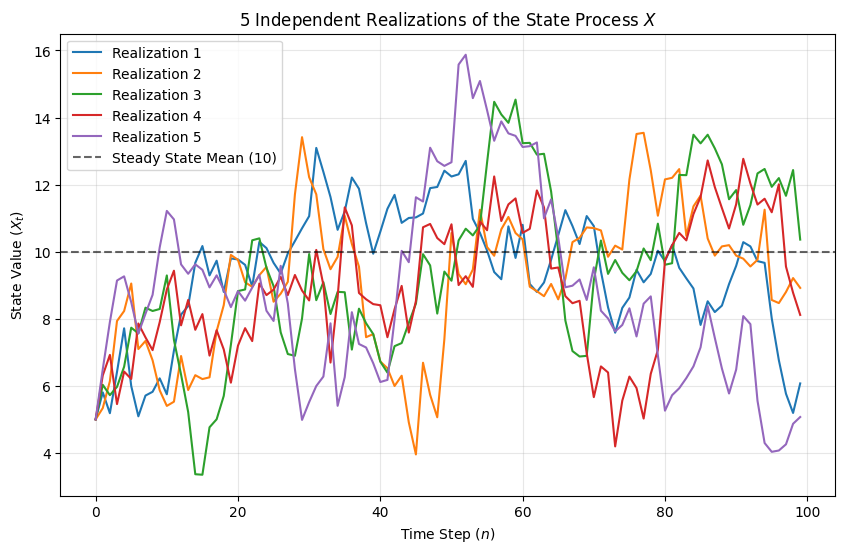

In [ ]:
# plot
plt.figure(figsize=(10, 6))

for i in range(num_realizations):
    X, Y = model(a, b, sigma_1, sigma_2)
    plt.plot(X, label=f'Realization {i+1}')

plt.axhline(y=b/(1-a), color='black', linestyle='--', alpha=0.6, label='Steady State Mean (10)')

plt.title(f'{num_realizations} Independent Realizations of the State Process $X$')
plt.xlabel('Time Step ($n$)')
plt.ylabel('State Value ($X_t$)')
plt.legend()
plt.grid(True, alpha=0.3)
# plt.savefig('process_trajectories.png')

## 1.2 Simulate a single realization of the process

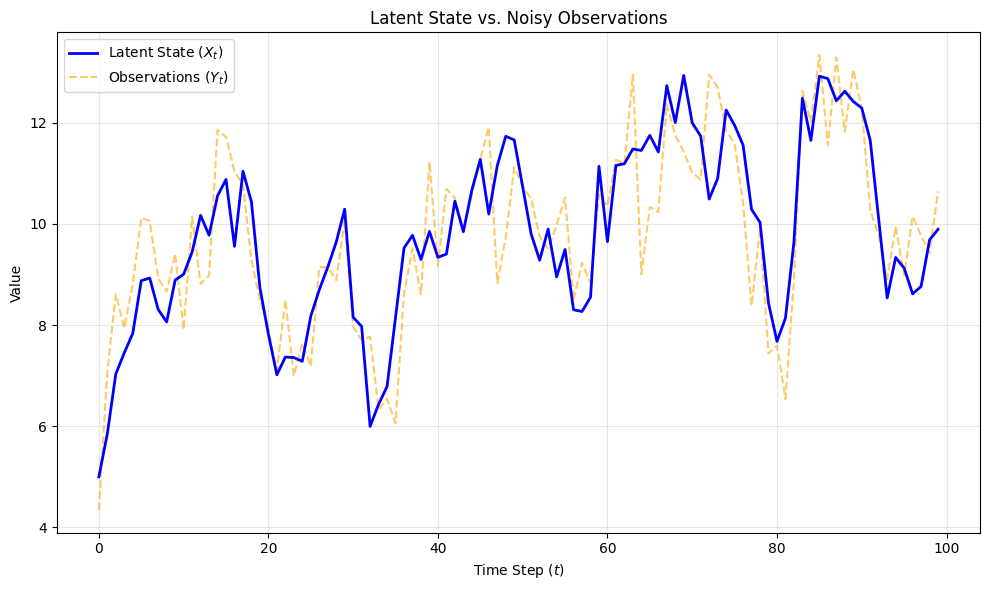

In [9]:
# Plot the latent state trajectory Xt along with the noisy observations Yt in a single figure.

X, Y = model(a, b, sigma_1, sigma_2)

plt.figure(figsize=(10, 6))
# Plot latent state (the "Truth")
plt.plot(X, label='Latent State ($X_t$)', color='blue', linewidth=2, zorder=2)

# Plot observations (the "Noisy Data")
plt.plot(Y, label='Observations ($Y_t$)', color='orange', linestyle='--', alpha=0.6, zorder=1)

# Formatting
plt.title('Latent State vs. Noisy Observations')
plt.xlabel('Time Step ($t$)')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('process_trajectories.png')

## 1.3 

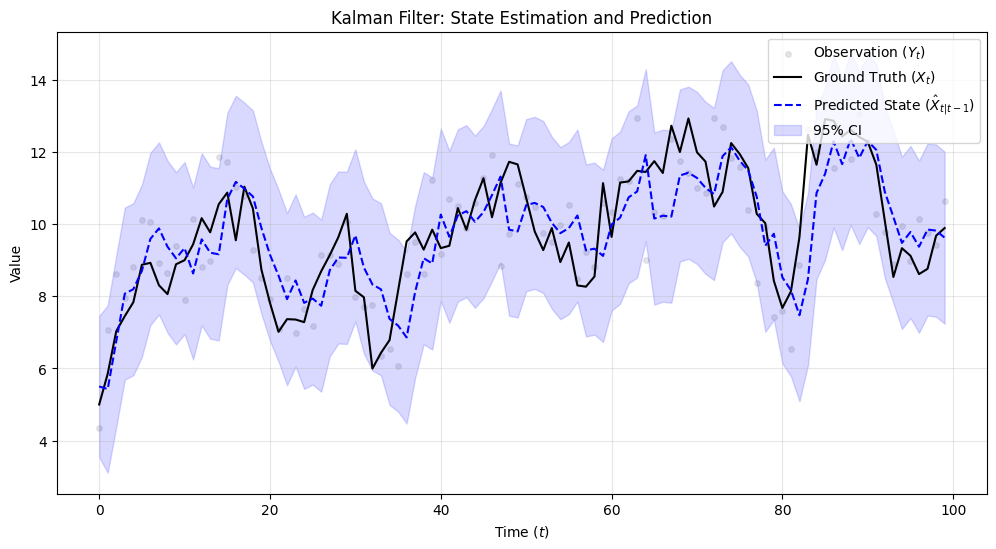

In [ ]:
# model is
# X[i] = a*X[i-1] + b + noise
# Kalman
# X_{t+1} = theta[0] - theta[1]*X_t    =>   theta[0] = b, theta[1] = -a

KF = myKalmanFilter(Y, [b, -a, 1], R=1, x_prior=5, P_prior=0)

x_pred = KF["x_pred"]
P_pred = KF["P_pred"]
N = len(Y)
time = np.arange(N)

# Calculate 95% Confidence Interval: mean +/- 1.96 * sqrt(variance)
std_error = np.sqrt(P_pred)
upper_ci = x_pred + 1.96 * std_error
lower_ci = x_pred - 1.96 * std_error

# Plotting
plt.figure(figsize=(12, 6))

# 1. Observation (Scatter usually looks best to distinguish from lines)
plt.scatter(time, Y, color='lightgray', alpha=0.6, label='Observation ($Y_t$)', s=15)

# 2. Ground Truth
plt.plot(time, X, color='black', linewidth=1.5, label='Ground Truth ($X_t$)')

# 3. Predicted State
# Note: x_pred[t] is X_{t|t-1}. Usually plotted at index t.
plt.plot(time, x_pred, color='blue', linestyle='--', label=r'Predicted State ($\hat{X}_{t|t-1}$)')

# 4. 95% Confidence Interval
plt.fill_between(time, lower_ci, upper_ci, color='blue', alpha=0.15, label='95% CI')

plt.title("Kalman Filter: State Estimation and Prediction")
plt.xlabel("Time ($t$)")
plt.ylabel("Value")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()